# SIS + external shear

This notebook explores and reproduces the work of [Finch, Carlivati, Winn & Schechter (2002), *Analytic expressions for mean magnification by a quadrupole gravitational lens*](https://arxiv.org/abs/astro-ph/0205489), ApJ 577, 51.

The lens is a singular isothermal sphere (SIS) embedded in an external shear $\gamma$ — the simplest lens model producing quadruple images. 

In this notebook we 

(i) derive the inverse magnification and the analytic caustics/critical curves with `sympy`, 

(ii) verify the paper's Table 1 (cross sections and mean magnifications, valid only for $\gamma<1/3$) including the numerical constant $I_1\simeq 1.35111$, 

(iii) reproduce Fig. 2 (probability distributions of the total magnification of doubles and quads at $\gamma=0.2$) by Monte Carlo inversion of the lens equation, and 

(iv) reproduce Fig. 3 (relative image-plane areas of the 2-, 3- and 4-image regions), **extending the calculation numerically to $\gamma>1/3$**, where the astroid caustic develops naked cusps, 3-image systems appear, and no closed-form results exist.

In [1]:
#-- DEFINITIONS --
import numpy as np
import sympy as sp

import sys, os
sys.path.append(os.path.abspath('..'))  # make gw_lensing importable when running from examples/
from gw_lensing.lens_models import sis_shear

In [2]:
#PLOTTING MODULES
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
fontSZ = 20
fontSz = 18
fontsz = 16

## Lens model

The (dimensionless) lens potential of an SIS with Einstein radius $b$ plus external shear $\gamma$ is (Eq. 6 of the paper)
\begin{equation}
\psi(r,\theta) = b\,r + \frac{\gamma}{2}\, r^2 \cos 2\theta ,
\end{equation}
with $(r,\theta)$ polar coordinates in the image plane. The lens equation maps an image position $\vec r$ to the source position $\vec s$ (Eq. 2),
\begin{equation}
\vec s = \vec r - \vec\nabla \psi(\vec r)\,,
\end{equation}
which in Cartesian coordinates ($x = r\cos\theta$, $y=r\sin\theta$, so that $\psi = b\sqrt{x^2+y^2} + \tfrac{\gamma}{2}(x^2-y^2)$) reads
\begin{equation}
s_x = (1-\gamma)\,x - b\,\frac{x}{r}\,, \qquad s_y = (1+\gamma)\,y - b\,\frac{y}{r}\,.
\end{equation}
The signed magnification of each image is the inverse Jacobian of this map (Eq. 3),
\begin{equation}
\mu^{-1} = (1-\psi_{xx})(1-\psi_{yy}) - \psi_{xy}^2\,.
\end{equation}
Magnifications are invariant under rescaling of $b$, so we set $b=1$ throughout the numerical examples.

## Inverse magnification (Eq. 7)

We let `sympy` differentiate the potential twice, build the Jacobian, and verify that it reduces to the compact polar form quoted in the paper,
\begin{equation}
\mu^{-1}(r,\theta) = 1-\gamma^2 - \frac{b}{r}\left(1-\gamma\cos 2\theta\right).
\end{equation}

In [3]:
x, y = sp.symbols('x y', real=True)
b_s, r_s = sp.symbols('b r', positive=True)
gam_s = sp.symbols('gamma', positive=True)
th_s = sp.symbols('theta', real=True)

psi = b_s*sp.sqrt(x**2 + y**2) + sp.Rational(1, 2)*gam_s*(x**2 - y**2)
psi_xx = sp.diff(psi, x, 2)
psi_yy = sp.diff(psi, y, 2)
psi_xy = sp.diff(psi, x, y)
mu_inv_cart = sp.simplify((1 - psi_xx)*(1 - psi_yy) - psi_xy**2)

# substitute polar coordinates and compare with Eq. 7
mu_inv_polar = mu_inv_cart.subs({x: r_s*sp.cos(th_s), y: r_s*sp.sin(th_s)})
eq7 = 1 - gam_s**2 - (b_s/r_s)*(1 - gam_s*sp.cos(2*th_s))
difference = sp.simplify(sp.expand_trig(sp.simplify(mu_inv_polar - eq7)))
print('mu^-1 - Eq.(7) simplifies to:', difference)
assert difference == 0
eq7

mu^-1 - Eq.(7) simplifies to: 0


-b*(-gamma*cos(2*theta) + 1)/r - gamma**2 + 1

## Caustics, critical curve and transition loci (Eqs. 8–14)

Four closed curves organize the image multiplicity:

- **Radial caustic** (Eq. 8): the SIS deflection $b\,\hat r$ is discontinuous at $r=0$, so the innermost image appears/disappears when the source crosses the curve traced by the $r\to0$ limit of the lens equation, $(x_r, y_r) = (-b\cos\theta, -b\sin\theta)$ — a circle of radius $b$, area $A_r = \pi b^2$. Sources inside it gain one extra image.
- **1–2 transition locus** (Eq. 10): the image-plane curve that maps onto the radial caustic. Putting $\vec s$ on the radial caustic and solving the lens equation for $r$ gives
\begin{equation}
 r_t(\theta_t) = \frac{2b\,(1-\gamma\cos 2\theta_t)}{1-2\gamma\cos2\theta_t+\gamma^2}\,, \qquad A_t = \frac{4\pi b^2\, (1-\gamma^2/2)}{1-\gamma^2} \quad \text{(Eq. 11)}\,.
\end{equation}
- **Critical curve** (Eq. 12): the zero locus of $\mu^{-1}$ from Eq. 7,
\begin{equation}
 r_c(\theta_c) = \frac{b\,(1-\gamma\cos 2\theta_c)}{1-\gamma^2}\,.
\end{equation}
- **Astroid caustic** (Eqs. 13–14): the image of the critical curve under the lens map,
\begin{equation}
x_a = -\frac{2b\gamma}{1+\gamma}\cos^3\theta_c\,,\qquad y_a = \frac{2b\gamma}{1-\gamma}\sin^3\theta_c\,, \qquad A_a = \frac{3\pi}{2}\frac{b^2\gamma^2}{1-\gamma^2}\,.
\end{equation}
Sources inside it gain two extra images (quads).

The **2–4 transition loci** (image-plane curves mapping onto the astroid, Eqs. 17–18) are parametrized by $t=\cos\theta_c$:
\begin{equation}
\cos\theta_{i,o} = t\left(t^2-1 \pm \sqrt{t^4-t^2+1}\right), \qquad
 r_4(t) = \frac{b}{1-\gamma}\left[1 - \frac{2\gamma\, t^3}{(1+\gamma)\cos\theta_4(t)}\right].
\end{equation}

The astroid's vertical extent is $2b\gamma/(1-\gamma)$, while the radial caustic has radius $b$: the astroid fits entirely inside the radial caustic **only for $\gamma<1/3$** — the key threshold of the whole paper. As a validation checkpoint (paper's Fig. 1) we draw all the curves for $\gamma=0.2$ (astroid fully inside) and $\gamma=0.45$ (cusps poking outside).

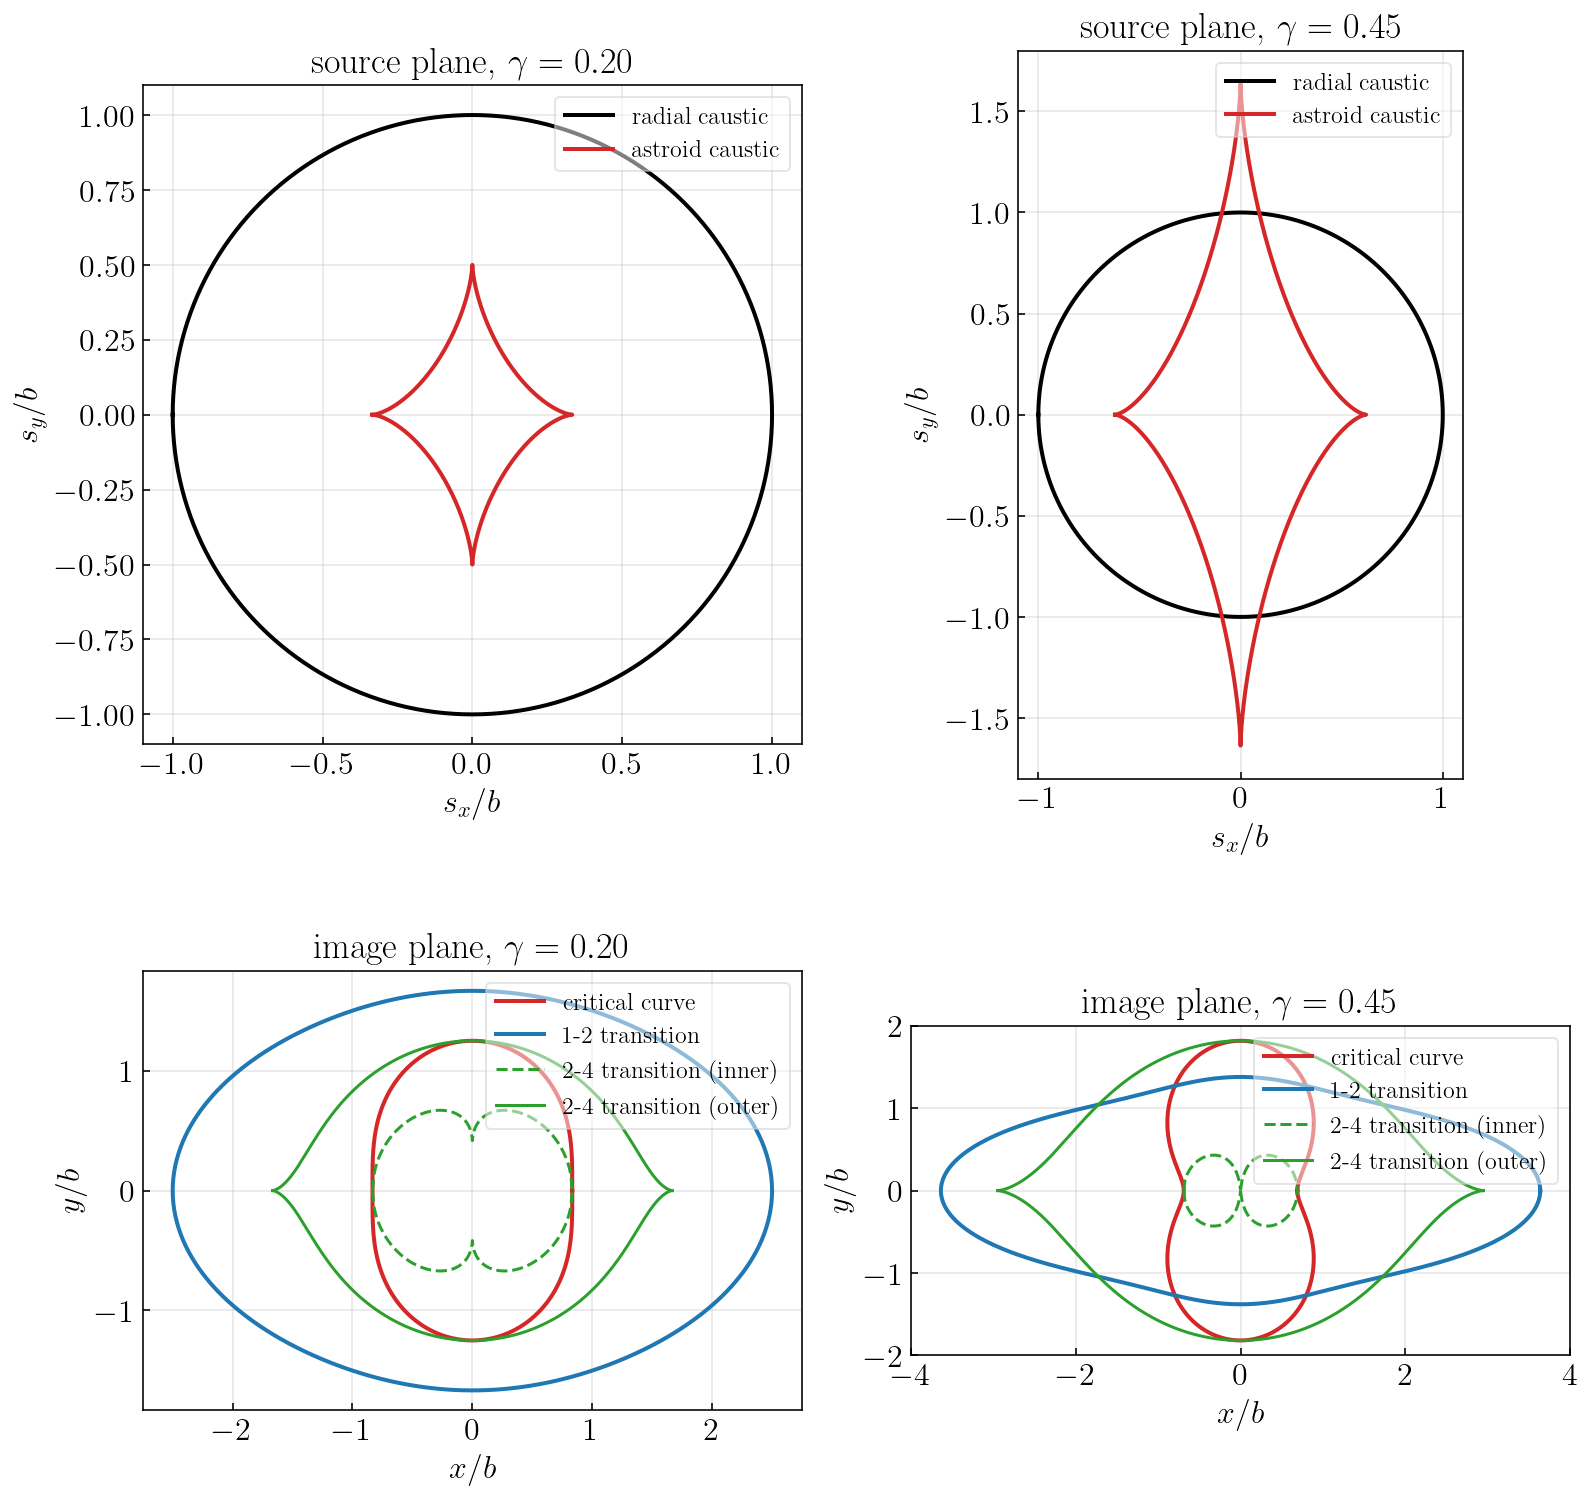

In [6]:
b = 1.0
theta = np.linspace(0., 2.*np.pi, 601)
t_par = np.linspace(-1., 1., 601)

fig, axes = plt.subplots(2, 2, figsize=(11, 11))
for j, gamma in enumerate([0.2, 0.45]):
    # source plane
    ax = axes[0, j]
    ax.plot(*sis_shear.radial_caustic(theta, b), 'k', lw=2, label='radial caustic')
    ax.plot(*sis_shear.astroid_caustic(theta, b, gamma), 'C3', lw=2, label='astroid caustic')
    ax.set_title(r'source plane, $\gamma=%.2f$' % gamma, fontsize=fontSz)
    ax.set_xlabel(r'$s_x/b$', fontsize=fontsz)
    ax.set_ylabel(r'$s_y/b$', fontsize=fontsz)
    # image plane
    ax = axes[1, j]
    ax.plot(*sis_shear.critical_curve(theta, b, gamma), 'C3', lw=2, label='critical curve')
    ax.plot(*sis_shear.transition_locus_12(theta, b, gamma), 'C0', lw=2, label='1-2 transition')
    x_in, y_in, x_out, y_out = sis_shear.transition_locus_24(t_par, b, gamma)
    for xx, yy, lab in [(x_in, y_in, '2-4 transition (inner)'), (x_out, y_out, '2-4 transition (outer)')]:
        ax.plot(xx, yy, 'C2', lw=1.5, ls='--' if 'inner' in lab else '-', label=lab)
        ax.plot(xx, -yy, 'C2', lw=1.5, ls='--' if 'inner' in lab else '-')
    ax.set_title(r'image plane, $\gamma=%.2f$' % gamma, fontsize=fontSz)
    ax.set_xlabel(r'$x/b$', fontsize=fontsz)
    ax.set_ylabel(r'$y/b$', fontsize=fontsz)

for ax in axes.ravel():
    ax.set_aspect('equal')
    ax.tick_params(axis='both', which='both', direction='in', labelsize=fontsz)
    ax.legend(fontsize=fontsz-4, framealpha=0.5, loc='upper right')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

At $\gamma=0.2$ the astroid is well inside the radial caustic: doubles and quads exhaust the multiple-image systems. 

At $\gamma=0.45$ the cusps on the $y$-axis stick out of the circle (*naked cusps*): sources inside a naked-cusp lobe but outside the circle have 3 images. Correspondingly, in the image plane the inner 2–4 transition locus reaches $r_4<0$ near $\theta=\pi/2$ (masked as NaN above) and the closed-form bookkeeping of the paper breaks down.

## The $I_1$ integral and Table 1 ($\gamma<1/3$)

The image-plane area of the 4-image band between the two transition loci is (Eqs. 19–21)
\begin{equation}
A_o - A_i = \frac{4\pi b^2 \gamma\,(I_1 + I_2\,\gamma)}{(1-\gamma^2)^2}\,,
\end{equation}
where $I_2=0$ identically (its integrand is antisymmetric) and
\begin{equation}
I_1 = \frac{2}{\pi}\int_0^{\pi/2} \frac{t_i^3(\theta)-t_o^3(\theta)}{\cos\theta}\,{\rm d}\theta \simeq 1.35111\,,
\end{equation}
with $t_{i,o}(\theta)$ the inverse relations of Eq. 17. Rather than inverting Eq. 17 numerically for every $\theta$, `sis_shear.I1_constant` evaluates the enclosed areas $A_{i,o} = \int_0^\pi r_4^2\,{\rm d}\theta$ directly with the $r_4(t)$ parametrization (integrating over $t=\sin u$, which removes the endpoint singularities of ${\rm d}\theta/{\rm d}t$) and extracts $I_1$ from the area difference; because $I_2=0$ exactly, the result is independent of the reference shear used — which we check.

With $I_1$ in hand, Table 1 of the paper gives, **for $\gamma<1/3$**, the source-plane cross sections and mean total magnifications
\begin{equation}
\sigma_2 = \pi b^2\,\frac{1-\tfrac52\gamma^2}{1-\gamma^2}\,, \qquad \sigma_4 = \frac{3\pi}{2}\frac{b^2\gamma^2}{1-\gamma^2} = A_a\,,
\end{equation}

\begin{equation}
\langle\mu_2\rangle = \frac{4\left[(1-\gamma^2/2)(1-\gamma^2) - I_1\gamma\right]}{(1-\tfrac52\gamma^2)(1-\gamma^2)}\,, \qquad \langle\mu_4\rangle = \frac{8 I_1}{3\gamma(1-\gamma^2)} \simeq \frac{3.6}{\gamma(1-\gamma^2)}\,,
\end{equation}

and the minimum total magnifications (Eqs. 23–24)
\begin{equation}
\mu_{2,\rm min} = \frac{2}{(1+3\gamma)(1-\gamma)}\,, \qquad \mu_{4,\rm min} = \frac{2}{\gamma(1-\gamma^2)}\,.
\end{equation}

I1 = 1.351115   (paper: 1.35111)
independence of the reference shear: I1(0.05) = 1.35111504, I1(0.30) = 1.35111507


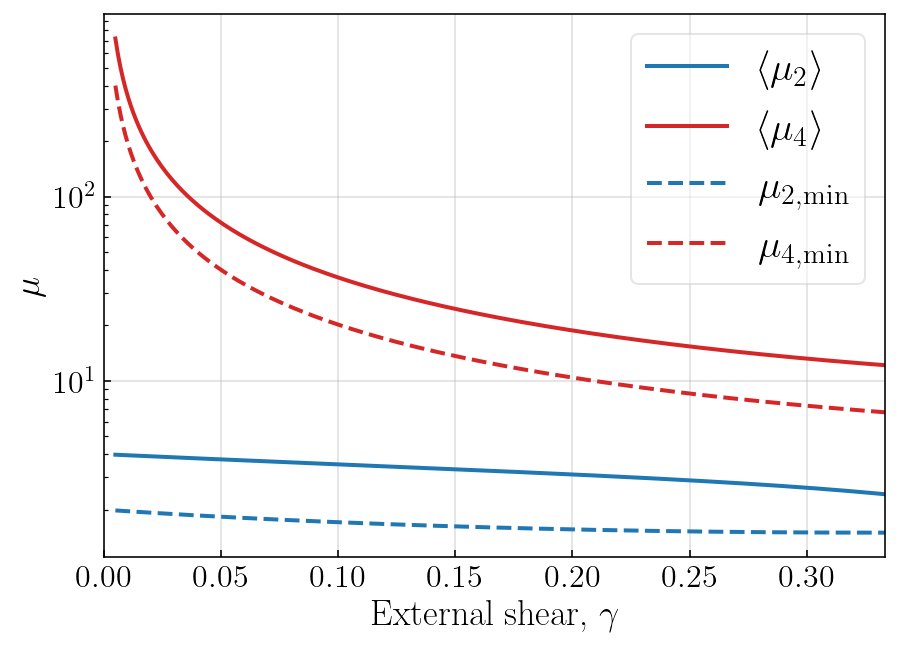

In [7]:
I1 = sis_shear.I1_constant()
print('I1 = %.6f   (paper: 1.35111)' % I1)
print('independence of the reference shear: I1(0.05) = %.8f, I1(0.30) = %.8f'
      % (sis_shear.I1_constant(0.05), sis_shear.I1_constant(0.30)))
assert abs(I1 - 1.35111) < 1e-4

gams = np.linspace(0.005, 1./3., 300)
plt.figure(figsize=(7, 5))
plt.semilogy(gams, sis_shear.mu2_mean_analytic(gams), 'C0', lw=2, label=r'$\langle\mu_2\rangle$')
plt.semilogy(gams, sis_shear.mu4_mean_analytic(gams), 'C3', lw=2, label=r'$\langle\mu_4\rangle$')
plt.semilogy(gams, sis_shear.mu2_min(gams), 'C0--', lw=2, label=r'$\mu_{2,\rm min}$')
plt.semilogy(gams, sis_shear.mu4_min(gams), 'C3--', lw=2, label=r'$\mu_{4,\rm min}$')
plt.xlabel(r'External shear, $\gamma$', fontsize=fontSz)
plt.ylabel(r'$\mu$', fontsize=fontSz)
plt.tick_params(axis='both', which='both', direction='in', labelsize=fontsz)
plt.legend(fontsize=fontSZ, framealpha=0.5)
plt.grid(alpha=0.4)
plt.xlim([0., 1./3.])
plt.show()

## Numerical image finder: the lens equation as a quartic in $r$

To reproduce Figs. 2 and 3 we must invert the lens equation for an *arbitrary* source $(s_x,s_y)$ and find **all** of its images (1, 2, 3 or 4 of them). Solving each Cartesian component of the lens equation for the corresponding coordinate,
\begin{equation}
x = \frac{s_x\, r}{(1-\gamma)r - b}\,, \qquad y = \frac{s_y\, r}{(1+\gamma)r - b}\,,
\end{equation}
and substituting into $r^2 = x^2+y^2$ gives, after clearing denominators, a single polynomial of degree 4 in $r$, independent of $\theta$:
\begin{equation}
\left[(1-\gamma)r-b\right]^2\left[(1+\gamma)r-b\right]^2 - s_x^2\left[(1+\gamma)r-b\right]^2 - s_y^2\left[(1-\gamma)r-b\right]^2 = 0\,.
\end{equation}
Every **real, positive** root $r$ (with nonvanishing denominators) corresponds to exactly one image, recovered through $x(r)$, $y(r)$ above. Since we substituted directly (nothing was squared), there is no spurious-sign ambiguity: the number of such roots *is* the image multiplicity of that source.

We now derive the quartic coefficients symbolically and check them against the plain-`numpy` implementation in `gw_lensing.lens_models.sis_shear`.

In [10]:
sx_s, sy_s = sp.symbols('s_x s_y', real=True)
den_x = (1 - gam_s)*r_s - b_s
den_y = (1 + gam_s)*r_s - b_s
quartic = sp.expand(den_x**2*den_y**2 - sx_s**2*den_y**2 - sy_s**2*den_x**2)
coeffs_sym = sp.Poly(quartic, r_s).all_coeffs()
for k, c in enumerate(coeffs_sym):
    print('c%d =' % (4 - k), sp.factor(c))

# fast numerical version of the symbolic coefficients
quartic_coeffs_lam = sp.lambdify((sx_s, sy_s, b_s, gam_s), coeffs_sym, 'numpy')

# check against the hand-coded coefficients in the module
rng = np.random.default_rng(0)
sx_test, sy_test = rng.uniform(-2., 2., 1000), rng.uniform(-2., 2., 1000)
c_lam = quartic_coeffs_lam(sx_test, sy_test, 1.3, 0.27)
c_mod = sis_shear.quartic_coefficients(sx_test, sy_test, 1.3, 0.27)
for c1, c2 in zip(c_lam, c_mod):
    assert np.allclose(np.broadcast_to(c1, sx_test.shape), np.broadcast_to(c2, sx_test.shape))
print('\nsympy-derived coefficients == sis_shear.quartic_coefficients: OK')

c4 = (gamma - 1)**2*(gamma + 1)**2
c3 = 4*b*(gamma - 1)*(gamma + 1)
c2 = -2*b**2*gamma**2 + 6*b**2 - gamma**2*s_x**2 - gamma**2*s_y**2 - 2*gamma*s_x**2 + 2*gamma*s_y**2 - s_x**2 - s_y**2
c1 = -2*b*(2*b**2 - gamma*s_x**2 + gamma*s_y**2 - s_x**2 - s_y**2)
c0 = b**2*(b**2 - s_x**2 - s_y**2)

sympy-derived coefficients == sis_shear.quartic_coefficients: OK


`sis_shear.find_images` solves one quartic with `numpy.roots`. For the Monte Carlo runs below we need the roots of $\sim10^5$–$10^6$ quartics: instead of looping over `numpy.roots`, `sis_shear.find_images_batch` stacks the $4\times4$ companion matrices of all the (monic) quartics into a single $(N,4,4)$ array and diagonalizes them with **one** broadcast call to `numpy.linalg.eigvals`, returning per source the image multiplicity and the total unsigned magnification $\mu_{\rm tot} = \sum_i |\mu_i|$.

We validate the solver: for a few test sources at $\gamma=0.2$ we check the expected multiplicity, that the recovered images satisfy the forward lens equation, that $r^2 = x^2+y^2$, and that the batch and single-source versions agree.

In [11]:
gamma = 0.2
test_sources = [(0.05, 0.03),   # inside the astroid -> 4 images
                (0.5, 0.5),     # inside the radial caustic, outside the astroid -> 2 images
                (1.5, 0.3)]     # outside everything -> 1 image
for sx0, sy0 in test_sources:
    images = sis_shear.find_images(sx0, sy0, b, gamma)
    residuals, r2_checks = [], []
    for x_i, y_i, mu_i in images:
        r_i = np.hypot(x_i, y_i)
        residuals.append(np.hypot((1 - gamma)*x_i - b*x_i/r_i - sx0,
                                  (1 + gamma)*y_i - b*y_i/r_i - sy0))
        # Eq. 7 consistency: mu stored is 1/mu_inv at the image position
        assert np.isclose(1./mu_i, sis_shear.mu_inv(x_i, y_i, b, gamma))
    print('s = (%.2f, %.2f): %d images, max lens-eq residual = %.1e, mu_tot = %.4f'
          % (sx0, sy0, len(images), max(residuals), np.abs(images[:, 2]).sum()))

# batch vs single-source agreement on random sources
rng = np.random.default_rng(1)
sx_r, sy_r = rng.uniform(-1., 1., 500), rng.uniform(-1., 1., 500)
n_img, mu_tot = sis_shear.find_images_batch(sx_r, sy_r, b, gamma)
for i in range(500):
    images = sis_shear.find_images(sx_r[i], sy_r[i], b, gamma)
    assert len(images) == n_img[i]
    assert np.isclose(np.abs(images[:, 2]).sum(), mu_tot[i], rtol=1e-8)
print('\nbatch (companion-matrix eigvals) vs single-source (numpy.roots): OK')

s = (0.05, 0.03): 4 images, max lens-eq residual = 1.2e-11, mu_tot = 10.6648
s = (0.50, 0.50): 2 images, max lens-eq residual = 5.8e-15, mu_tot = 2.3216
s = (1.50, 0.30): 1 images, max lens-eq residual = 2.0e-15, mu_tot = 1.4217

batch (companion-matrix eigvals) vs single-source (numpy.roots): OK


## Magnification distributions of doubles and quads at $\gamma=0.2$

We sample $N=10^6$ sources uniformly inside the radial-caustic disk of radius $b$ (via $r = b\sqrt{u_1}$, $\theta = 2\pi u_2$), find all their images, split the sample by image multiplicity (only 2 and 4 occur, since $\gamma<1/3$) and histogram the total magnification $\mu_{\rm tot}$ of each subset. The fraction of quads should be $\sigma_4/\pi b^2$ and the subset means should reproduce $\langle\mu_2\rangle$, $\langle\mu_4\rangle$ from Table 1.

In [12]:
gamma = 0.2
N = 1_000_000
rng = np.random.default_rng(42)
r_src = b*np.sqrt(rng.random(N))
th_src = 2.*np.pi*rng.random(N)
n_img, mu_tot = sis_shear.find_images_batch(r_src*np.cos(th_src), r_src*np.sin(th_src), b, gamma)

doubles = n_img == 2
quads = n_img == 4
print('multiplicities found:', sorted(np.unique(n_img)))
print('fraction of quads   : MC = %.4f, analytic sigma_4/(pi b^2) = %.4f'
      % (quads.mean(), sis_shear.sigma4_analytic(b, gamma)/(np.pi*b**2)))
print('fraction of doubles : MC = %.4f, analytic sigma_2/(pi b^2) = %.4f'
      % (doubles.mean(), sis_shear.sigma2_analytic(b, gamma)/(np.pi*b**2)))
print('<mu_2> : MC = %.3f, analytic = %.3f' % (mu_tot[doubles].mean(), sis_shear.mu2_mean_analytic(gamma)))
print('<mu_4> : MC = %.3f, analytic = %.3f' % (mu_tot[quads].mean(), sis_shear.mu4_mean_analytic(gamma)))
print('min mu_tot doubles = %.4f  (mu_2,min = %.4f)' % (mu_tot[doubles].min(), sis_shear.mu2_min(gamma)))
print('min mu_tot quads   = %.4f  (mu_4,min = %.4f)' % (mu_tot[quads].min(), sis_shear.mu4_min(gamma)))

multiplicities found: [2, 4]
fraction of quads   : MC = 0.0622, analytic sigma_4/(pi b^2) = 0.0625
fraction of doubles : MC = 0.9378, analytic sigma_2/(pi b^2) = 0.9375
<mu_2> : MC = 3.103, analytic = 3.105
<mu_4> : MC = 18.785, analytic = 18.765
min mu_tot doubles = 1.5626  (mu_2,min = 1.5625)
min mu_tot quads   = 10.4167  (mu_4,min = 10.4167)


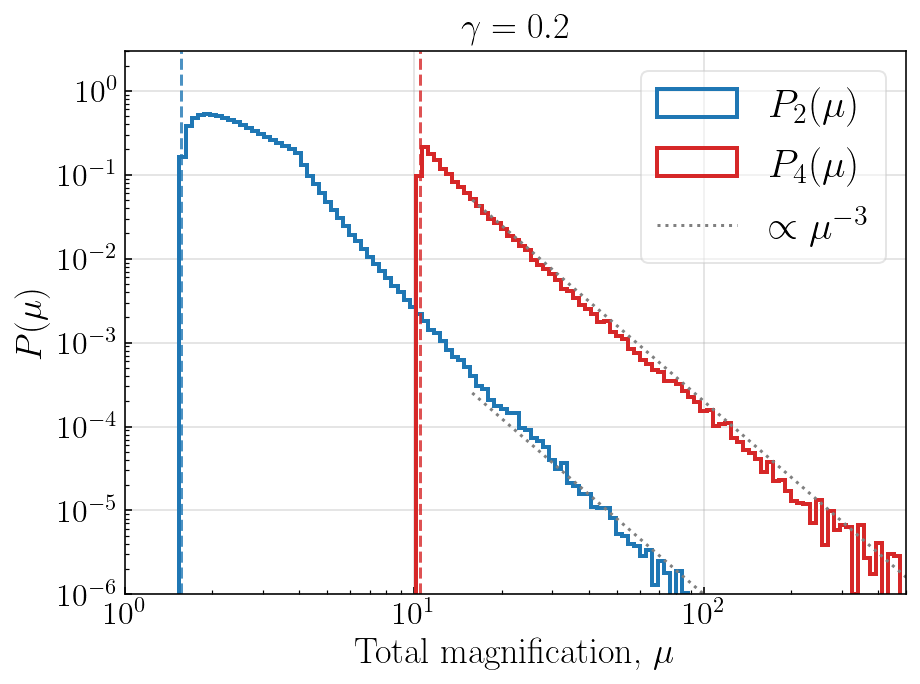

In [15]:
bins = np.logspace(0., 2.7, 130)

plt.figure(figsize=(7, 5))
plt.hist(mu_tot[doubles], bins=bins, density=True, histtype='step', lw=2, color='C0', label=r'$P_2(\mu)$')
plt.hist(mu_tot[quads], bins=bins, density=True, histtype='step', lw=2, color='C3', label=r'$P_4(\mu)$')
plt.axvline(sis_shear.mu2_min(gamma), ls='--', color='C0', alpha=0.8)
plt.axvline(sis_shear.mu4_min(gamma), ls='--', color='C3', alpha=0.8)
mus = np.logspace(1.2, 2.7, 50)
plt.plot(mus, 2e2*np.power(mus, -3.), 'gray', lw=1.5, ls=':', label=r'$\propto\mu^{-3}$')
plt.plot(mus, 1e0*np.power(mus, -3.), 'gray', lw=1.5, ls=':')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Total magnification, $\mu$', fontsize=fontSz)
plt.ylabel(r'$P(\mu)$', fontsize=fontSz)
plt.title(r'$\gamma=%.1f$' % gamma, fontsize=fontSz)
plt.tick_params(axis='both', which='both', direction='in', labelsize=fontsz)
plt.legend(fontsize=fontSZ, framealpha=0.5)
plt.xlim([1., 500.])
plt.ylim([1e-6, 3.])
plt.grid(alpha=0.4)
plt.show()

The dashed vertical lines are the analytic minimum magnifications, $\mu_{2,\rm min} = 2/[(1+3\gamma)(1-\gamma)] \simeq 1.56$ and $\mu_{4,\rm min} = 2/[\gamma(1-\gamma^2)] \simeq 10.4$: both histograms cut off exactly there, quads only exist at high magnification, and both distributions develop the universal $\mu^{-3}$ caustic tail 

## The $\gamma=1/3$ threshold: naked cusps

The astroid caustic extends to $|y_a|_{\max} = 2b\gamma/(1-\gamma)$ along the $y$-axis, while the radial caustic has radius $b$. Once
\begin{equation}
\frac{2b\gamma}{1-\gamma} > b \quad\Longleftrightarrow\quad \gamma > \frac{1}{3}\,,
\end{equation}
the astroid cusps poke *outside* the radial caustic and become **naked cusps**: a source inside a naked-cusp lobe but outside the circle produces **3 images**. The clean partition of multiple-image sources into doubles and quads is lost, the transition loci no longer close (we saw $r_4<0$ above), and the Table 1 expressions cease to be valid — the paper itself resorts to numerics for its Fig. 3. We do the same here with the batched image finder.

For each multiplicity $n$, the *image-plane area* of the $n$-image region equals $\sigma_n\langle\mu_n\rangle$: by conservation of surface brightness, the total image area produced by a source region is
\begin{equation}
A_n^{\rm image} = \int_{n\text{-image region}} \mu_{\rm tot}(\vec s)\;{\rm d}^2 s\,, \qquad \mu_{\rm tot}(\vec s) = \sum_i |\mu_i(\vec s)|\,,
\end{equation}
since $\mu_{\rm tot}$ is exactly the local area-magnification factor of the lens map. We therefore estimate it with a *magnification-weighted* Monte Carlo sum,
\begin{equation}
A_n^{\rm image} \simeq \frac{A_{\rm domain}}{N}\sum_{\vec s\,:\;n(\vec s)=n} \mu_{\rm tot}(\vec s)\,,
\end{equation}
sampling sources uniformly in a disk of radius $R = 1.3\,\max\!\left[b,\; 2b\gamma/(1-\gamma)\right]$, which grows with $\gamma$ so as to always contain the naked-cusp lobes.

In [16]:
gammas = np.linspace(0.02, 0.95, 30)
N_src = 300_000
rng = np.random.default_rng(3)

fractions = np.zeros((len(gammas), 3))  # columns: 2-, 3-, 4-image
for i, g in enumerate(gammas):
    R = 1.3*max(b, 2.*b*g/(1. + g), 2.*b*g/(1. - g))
    r_src = R*np.sqrt(rng.random(N_src))
    th_src = 2.*np.pi*rng.random(N_src)
    n_img, mu_tot = sis_shear.find_images_batch(r_src*np.cos(th_src), r_src*np.sin(th_src), b, g)
    dA = np.pi*R**2/N_src  # common prefactor; cancels in the normalization
    areas = np.array([dA*mu_tot[n_img == k].sum() for k in (2, 3, 4)])
    fractions[i] = areas/areas.sum()

print(' gamma   f_2      f_3      f_4')
for g_show in (0.34, 0.45, 0.63):
    i = np.argmin(np.abs(gammas - g_show))
    print(' %.3f   %.4f   %.4f   %.4f' % (gammas[i], *fractions[i]))
print('\n3-image fraction below gamma=1/3 (should be ~0): max =',
      fractions[gammas < 1./3., 1].max())

 gamma   f_2      f_3      f_4
 0.341   0.4483   0.0023   0.5494
 0.437   0.2889   0.1166   0.5944
 0.629   0.0884   0.4845   0.4271

3-image fraction below gamma=1/3 (should be ~0): max = 0.0


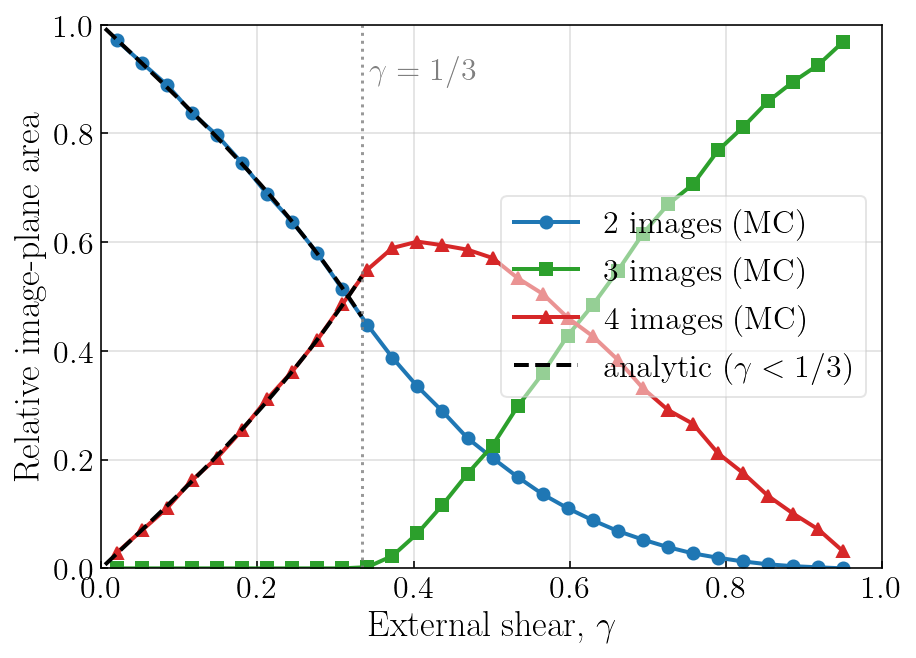

max |MC - analytic| for gamma < 0.3: f_2 -> 0.0044, f_4 -> 0.0044


In [17]:
# analytic prediction for gamma < 1/3: image-plane areas sigma_n <mu_n> from Table 1
gams_an = np.linspace(0.005, 1./3., 200)
A2_an = sis_shear.sigma2_analytic(b, gams_an)*sis_shear.mu2_mean_analytic(gams_an)
A4_an = sis_shear.sigma4_analytic(b, gams_an)*sis_shear.mu4_mean_analytic(gams_an)
f2_an = A2_an/(A2_an + A4_an)
f4_an = A4_an/(A2_an + A4_an)

plt.figure(figsize=(7, 5))
plt.plot(gammas, fractions[:, 0], 'o-', color='C0', lw=2, label=r'2 images (MC)')
plt.plot(gammas, fractions[:, 1], 's-', color='C2', lw=2, label=r'3 images (MC)')
plt.plot(gammas, fractions[:, 2], '^-', color='C3', lw=2, label=r'4 images (MC)')
plt.plot(gams_an, f2_an, 'k--', lw=2, label=r'analytic ($\gamma<1/3$)')
plt.plot(gams_an, f4_an, 'k--', lw=2)
plt.axvline(1./3., color='gray', ls=':', alpha=0.8)
plt.text(1./3. + 0.01, 0.9, r'$\gamma=1/3$', fontsize=fontsz, color='gray')
plt.xlabel(r'External shear, $\gamma$', fontsize=fontSz)
plt.ylabel(r'Relative image-plane area', fontsize=fontSz)
plt.tick_params(axis='both', which='both', direction='in', labelsize=fontsz)
plt.legend(fontsize=fontsz, framealpha=0.5, loc='center right')
plt.xlim([0., 1.])
plt.ylim([0., 1.])
plt.grid(alpha=0.4)
plt.show()

# quantitative checks
mask = gammas < 0.3
f2_interp = np.interp(gammas[mask], gams_an, f2_an)
f4_interp = np.interp(gammas[mask], gams_an, f4_an)
print('max |MC - analytic| for gamma < 0.3: f_2 -> %.4f, f_4 -> %.4f'
      % (np.abs(fractions[mask, 0] - f2_interp).max(), np.abs(fractions[mask, 2] - f4_interp).max()))